# MODELO TABNET APLICADO A PETFINDER:
Tabnet es una red neuronal creada por Google para procesar datos tabulares. Combina deep learning con la interpretabilidad y selección de características de los modelos de arboles de decisión. Se utilizo este modelo para complementar árboles de decisión buscando capturar variables que se les escapen a otros como LightGBM o Random Forest.

Se importan las librerías y los archivos que forman el dataset, incluído el archivo de train que aplicaremos a todos los modelos que probamos.

In [ ]:
# Se importan las librerias a utilizar 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, StratifiedKFold 
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score 
from sklearn.utils import shuffle 
import lightgbm as lgb
import optuna
import scipy as sp
from functools import partial
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.utils.class_weight import compute_sample_weight
import torch
from sklearn.preprocessing import LabelEncoder

# Se importan los archivos para formar los dataset 
breed_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\breed_labels.csv"))
color_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\color_labels.csv"))
state_df = pd.read_csv(os.path.join(r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\state_labels.csv"))
ruta_archivo = r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\df_train_FE_split.csv"
df_train = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')

Se agrega dataset de test

In [ ]:
ruta_archivo = r"C:\Users\fchiavassa\Desktop\Nueva carpeta\Inteligencia Artificial\Codigos\Maestria\df_test_FE_split.csv"

df_test = pd.read_csv(ruta_archivo, sep=',', encoding='latin-1')

Se comienza a adecuar el dataset para poder aplicas el modelo, definimos primero que columnas no queremos mostrar y en un paso posterior identificamos aquellos que son de texto ya que tabnet solo trabaja con datos numéricos y categóricos. Posteriormente nos aseguramos que no haya nulos y convertimos a string en casos categóricos y en caso numéricos nos aseguramos que todos los na se conviertan en numérico.

In [ ]:
# Definimos qué columnas NO queremos que el modelo vea (IDs y texto)
drop_cols = ['AdoptionSpeed', 'PetID', 'Name', 'RescuerID', 'Description', 'BreedID']
features = [c for c in df_train.columns if c not in drop_cols]

# Identificamos automáticamente TODAS las columnas que son texto (object) para que no genere problemas con el entrenamiento de la red
categorical_cols = df_train[features].select_dtypes(include=['object', 'category']).columns.tolist()

cat_idxs = []
cat_dims = []

for idx, col in enumerate(features):
    if col in categorical_cols:
        # Aseguramos que no haya nulos y convertimos a string antes de codificar
        df_train[col] = df_train[col].fillna("None").astype(str)
        
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        
        cat_idxs.append(idx)
        cat_dims.append(len(le.classes_))
    else:
        # Como las redes neuronales no aceptan nans nos aseguramos sean todas numericas
        df_train[col] = df_train[col].fillna(0)

# Verificación final: para ver si no hay problemas
print("Columnas que NO son números:", df_train[features].select_dtypes(exclude=[np.number]).columns.tolist())

Columnas que NO son números: []


C:\Users\fchiavassa\AppData\Local\Temp\ipykernel_1096\2276167611.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train[features].select_dtypes(include=['object', 'category']).columns.tolist()


# BUSQUEDA DE HIPERPARÁMETROS OPTIMOS:
Por defecto tabnet predice numeros continuos (Ej: 2,34), por lo que si usaramos un redondeo clásico perderíamos mucha capacidad de predicción. Por esto se le carga la clase OptimizerRounder en la cual inicialmente cargamos valores de inicio, pero mediante el uso de np.digitize los clasifica en 4 cortes, luego con kappa_loss trata de optimizar esta función medida como la diferencia entre el valor real y la predicción de la etiqueta de clase. por último el sp.optimize.minimize utiliza el método nelder-mead para mover esos 4 límites de forma iterativa hasta poder encontrar los cortes óptimos. Debimos ajustar el valor de inicio a 1, ya que si tomaba 0,5 no clasificaba ningún caso dentro de la categoría 0, por lo que los coeficientes iniciales si son relevantes.

Se configura optuna para buscar los mejores hiperparámetros, los parametros n_d y n_a le indican la cantidad de capas y el lambda spearse la penalidad por dispersión. El nstep nos indica cuantas pruebas hará antes de tomar la decisión, por ejemplo si ponemos 3, tomara 3 combinaciones de variables distintas y tomará la decisión al final de esas 3. Gamma es la reutilización de variables, mask_type decide que variables se miran y cuales se dejan en cada iteración y el optimizer_params le pasa los hiperparámetros al modelo por lo que se define el learning rate dentro de este apartado.

Debajo de esto se definen la cantidad de divisiones que tendrán los datos de entrenamiento, por ejemplo con folds 5, tomará 4 bloques de datos para entrenarse y 1 para validar. Al ser estratificado mantiene la misma proporción de mascotas de cada clase en cada fold. Por último corre 20 veces este proceso.


In [ ]:
class OptimizedRounder:
    def __init__(self):
        # Iniciamos con umbrales lógicos para las 5 clases (0 a 4)
        self.coef_ = [1.0, 2.0, 2.5, 3.0]

    def _kappa_loss(self, coef, X, y):
        X_p = np.digitize(X, np.sort(coef))
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        res = sp.optimize.minimize(loss_partial, self.coef_, method='nelder-mead')
        self.coef_ = np.sort(res['x'])

    def predict(self, X):
        return np.digitize(X, self.coef_)

# Se configura optuna para tabnet

def objective(trial):
    params = {
        'n_d': trial.suggest_int('n_d', 8, 64),
        'n_a': trial.suggest_int('n_a', 8, 64),
        'n_steps': trial.suggest_int('n_steps', 3, 10),
        'gamma': trial.suggest_float('gamma', 1.0, 2.0),
        'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-3, log=True),
        'optimizer_params': dict(lr=2e-2),
        'mask_type': 'entmax',
        'seed': 42,
        'verbose': 0
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    val_kappas = []
    
    # Nos aseguramos que usamos los datos procesados del CSV
    X = df_train[features].values
    y = df_train['AdoptionSpeed'].values

    for trn_idx, val_idx in skf.split(X, y):
        X_tr, y_tr = X[trn_idx], y[trn_idx] 
        X_val, y_val = X[val_idx], y[val_idx]
        
        regressor = TabNetRegressor(cat_idxs=cat_idxs, cat_dims=cat_dims, **params)
        
        regressor.fit(
            X_train=X_tr, y_train=y_tr.reshape(-1, 1),
            eval_set=[(X_val, y_val.reshape(-1, 1))],
            eval_metric=['rmse'],
            max_epochs=100, 
            patience=15, 
            batch_size=1024, 
            virtual_batch_size=128
        )
        
        # Predicciones crudas (decimales)
        preds_raw = regressor.predict(X_val).flatten()
        
        # Ajuste de umbrales para maximizar Kappa
        optR = OptimizedRounder()
        optR.fit(preds_raw, y_val)
        
        # Cálculo de la métrica objetivo del laboratorio
        kappa = cohen_kappa_score(y_val, optR.predict(preds_raw), weights='quadratic')
        val_kappas.append(kappa)

    return np.mean(val_kappas)

#  Crear y ejecutar el estudio
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(f"Mejor Kappa: {study.best_value}")
print(f"Mejores parámetros: {study.best_params}")

[I 2026-05-19 22:00:23,521] A new study created in memory with name: no-name-0eb4c937-1499-4f16-9774-11b6559bf60d



Early stopping occurred at epoch 49 with best_epoch = 34 and best_val_0_rmse = 1.0802


c:\Users\fchiavassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 49 with best_epoch = 34 and best_val_0_rmse = 1.09994


c:\Users\fchiavassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


...


Early stopping occurred at epoch 62 with best_epoch = 47 and best_val_0_rmse = 1.07244


c:\Users\fchiavassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 48 with best_epoch = 33 and best_val_0_rmse = 1.08601


c:\Users\fchiavassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
[I 2026-05-20 02:01:54,291] Trial 19 finished with value: 0.392178065216366 and parameters: {'n_d': 32, 'n_a': 31, 'n_steps': 5, 'gamma': 1.092657734911699, 'lambda_sparse': 0.0009764803090370383}. Best is trial 12 with value: 0.393949053517085.


Mejor Kappa: 0.393949053517085
Mejores parámetros: {'n_d': 62, 'n_a': 62, 'n_steps': 10, 'gamma': 1.0339877569002782, 'lambda_sparse': 0.0009980067972707944}


# ENTRENAMIENTO
En este apartado realizamos el entrenamiento del modelo.
En primer lugar extraemos la columna adoption speed para que sea la columna a predecir. 
En segundo lugar se configuran los mejores hiperparámetros obtenidos con OPTUNA.

In [ ]:
# Hacemos la separacion del set de validación final para medir los cortes reales
X_all = df_train[features].values
y_all = df_train['AdoptionSpeed'].values

X_train_fin, X_val_fin, y_train_fin, y_val_fin = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Configuramos y entrenar el modelo FINAL con los parámetros de Optuna
final_params = study.best_params
final_params.update({
    'cat_idxs': cat_idxs,
    'cat_dims': cat_dims,
    'cat_emb_dim': 2,
    'optimizer_fn': torch.optim.Adam,
    'optimizer_params': dict(lr=2e-2),
    'mask_type': 'entmax',
    'seed': 42,
    'verbose': 0
})

# AJUSTE DE PESOS
En una primera prueba el modelo fue muy conservador por lo que no le otorgó a ninguna mascota la etiqueta 0. Es por eso que avanzamos con el ajuste de los pesos para que las mascotas de la clase 0 minoritaria tengan algo preponderancia mientras que las de la clase 2 y 3 que son mayoritarias se mantengan iguales, con esto se utilizan los indices de corte calculados previamente para optimizar la distribución de categorías.

In [ ]:
# Se calculan los pesos balanceados que le asignará un peso alto a las mascotas de Clase 0 (minoritarias) 
# y un peso normal/bajo a las de Clase 2 o 3 (mayoritarias).
pesos_entrenamiento = compute_sample_weight('balanced', y_train_fin)

print("Entrenando el modelo final con Sample Weights...")
final_model = TabNetRegressor(**final_params)

# Se establecen los pesos en la función fit
final_model.fit(
    X_train=X_train_fin, 
    y_train=y_train_fin.reshape(-1, 1),
    eval_set=[(X_val_fin, y_val_fin.reshape(-1, 1))],
    eval_metric=['rmse'],
    max_epochs=150, 
    patience=20, 
    batch_size=1024, 
    virtual_batch_size=128,
    weights=pesos_entrenamiento
)

# Se calculan los Coeficientes Óptimos en el set de validación
preds_val = final_model.predict(X_val_fin).flatten()
optR = OptimizedRounder()
optR.fit(preds_val, y_val_fin)
cortes_optimos = optR.coef_

print(f"\n--- ANÁLISIS DE CORTES MATEMÁTICOS ---")
print(f"Corte 0 a 1: {cortes_optimos[0]:.4f}")
print(f"Corte 1 a 2: {cortes_optimos[1]:.4f}")
print(f"Corte 2 a 3: {cortes_optimos[2]:.4f}")
print(f"Corte 3 a 4: {cortes_optimos[3]:.4f}")

# GRÁFICOS
Para el análisis del modelo se generaron gráficos que muestran la importancia de las variables y los umbrales de corte. Especialmente en el gráfico de umbrales de corte vemos como las clases más representativas presentan cortes mas cercanos mientras que las demás tienen rangos más amplios.

Entrenando el modelo final con Sample Weights...

Early stopping occurred at epoch 61 with best_epoch = 41 and best_val_0_rmse = 1.14327


c:\Users\fchiavassa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



--- ANÁLISIS DE CORTES MATEMÁTICOS ---
Corte 0 a 1: 1.0559
Corte 1 a 2: 1.9283
Corte 2 a 3: 2.4331
Corte 3 a 4: 2.6430


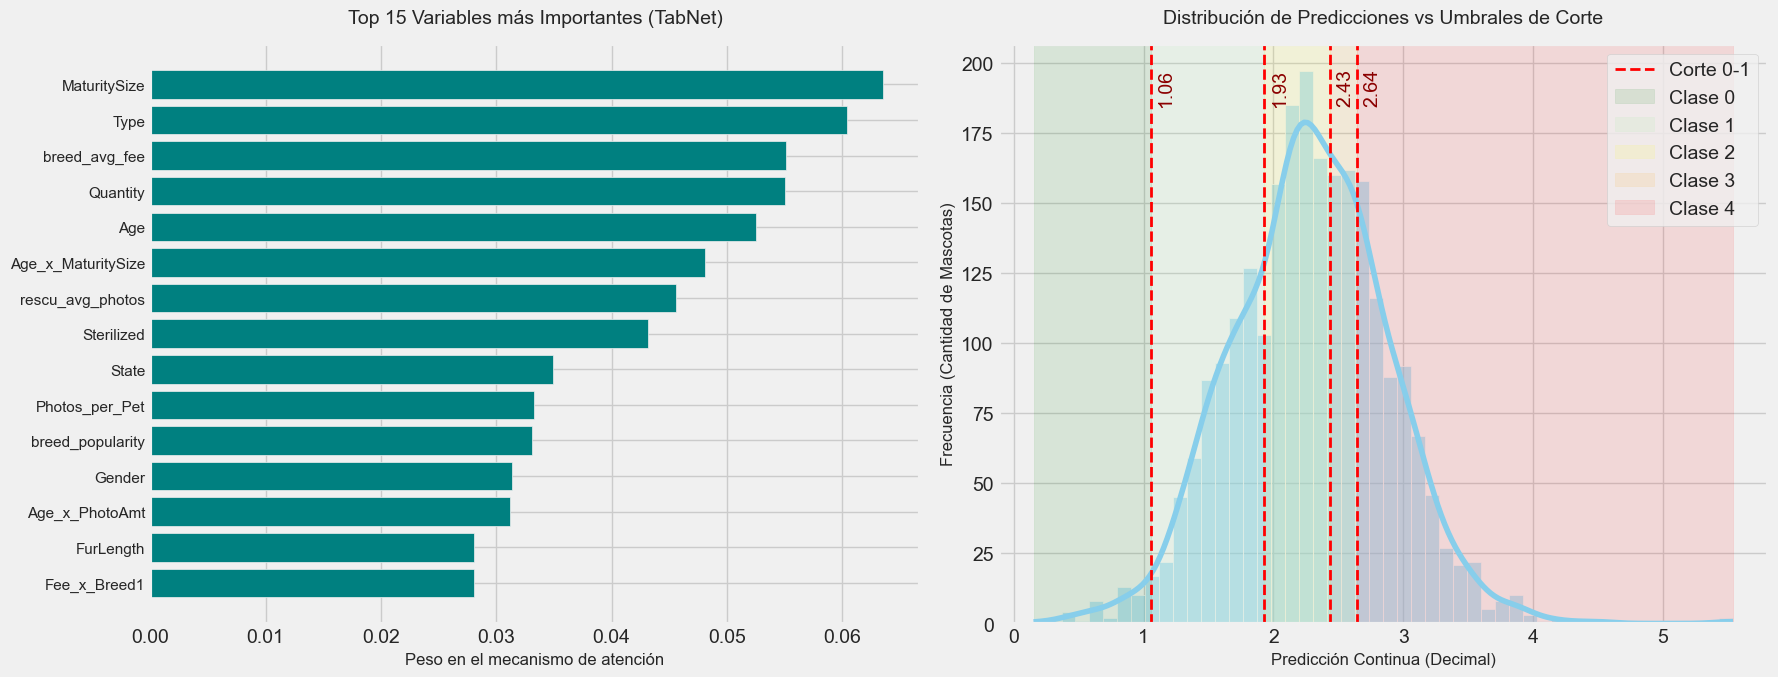

In [ ]:
# ZONA DE GRAFICACIÓN (PLOTS)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# GRÁFICO 1: Importancia de Variables (Feature Importance)
importances = final_model.feature_importances_
# Se filtra para mostrar solo el Top 15 de variables más importantes
indices = np.argsort(importances)[-15:] 

ax1.set_title("Top 15 Variables más Importantes (TabNet)", fontsize=14, pad=15)
ax1.barh(range(len(indices)), importances[indices], color='teal', align='center')
ax1.set_yticks(range(len(indices)))
ax1.set_yticklabels([features[i] for i in indices], fontsize=11)
ax1.set_xlabel('Peso en el mecanismo de atención', fontsize=12)

# GRÁFICO 2: Distribución de Predicciones vs Cortes
ax2.set_title("Distribución de Predicciones vs Umbrales de Corte", fontsize=14, pad=15)
sns.histplot(preds_val, bins=50, kde=True, color='skyblue', ax=ax2)

# Dibujar los umbrales de corte como líneas verticales rojas
for idx, corte in enumerate(cortes_optimos):
    ax2.axvline(corte, color='red', linestyle='--', linewidth=2, 
                label=f'Corte {idx}-{idx+1}' if idx==0 else "")
    ax2.text(corte + 0.05, ax2.get_ylim()[1]*0.9, f"{corte:.2f}", color='darkred', rotation=90)

# Colorear sutilmente los "segmentos" de cada clase
ax2.axvspan(preds_val.min(), cortes_optimos[0], alpha=0.1, color='green', label='Clase 0')
ax2.axvspan(cortes_optimos[0], cortes_optimos[1], alpha=0.1, color='lightgreen', label='Clase 1')
ax2.axvspan(cortes_optimos[1], cortes_optimos[2], alpha=0.1, color='yellow', label='Clase 2')
ax2.axvspan(cortes_optimos[2], cortes_optimos[3], alpha=0.1, color='orange', label='Clase 3')
ax2.axvspan(cortes_optimos[3], preds_val.max(), alpha=0.1, color='red', label='Clase 4')

ax2.set_xlabel('Predicción Continua (Decimal)', fontsize=12)
ax2.set_ylabel('Frecuencia (Cantidad de Mascotas)', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()